### Business Problem

**Netflix wants to grow their business in different countries and grow their revenue.  
Analyze the content type, geographical locations, duration and rating trends over the time to help Netflix promote relevant content to different countries.**

### Data Exploration

In [1]:
# !gdown "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/000/940/original/netflix.csv"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("netflix.csv")
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
data.shape

(8807, 12)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [6]:
data.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

1. Netflix dataset content has 8807 rows and 12 columns.
2. Most the columns are string that is categorical data except "release_year" which is integer that is numerical data.
3. Columns "director", "cast", "country", "date_added", "rating" and "duration" have missing values.  
Missing value count for columns:  
director - 2634  
cast - 825  
country - 831  
date_added - 10  
rating - 4  
duration - 3

In [7]:
data.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [8]:
# Count of content type
data["type"].value_counts(normalize=True)

type
Movie      0.696151
TV Show    0.303849
Name: proportion, dtype: float64

**Around 70% of content are movies while 30% are TV shows, suggesting that Netflix has heavily invested in it's movie content than TV shows.**

In [9]:
# Top genres on Netflix
data["listed_in"].value_counts(ascending=False).head()

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Name: count, dtype: int64

**Genres column needs some unnesting but in initial observation, content with theme of "Dramas, International Movies" and "Documentaries" are appearing frequently followed by Stand-Up Comedy.**

In [10]:
# Top countries where Netflix content was produced
data["country"].value_counts(ascending=False).head()

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Name: count, dtype: int64

**Majority of the Netflix content was produced in United States followed by India, the UK, Japan and South Korea**

In [11]:
# What is the ratings distribution
data["rating"].value_counts(ascending=False).head()

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64

**Around 36% content has TV-MA rating, 24% content is TV-14 and 9% content is TV-PG, accumulating to 70% content on Netflix is intended for mature audience or unsuitable for younger children, which suggests Netflix content heavily focused on teens and mature audience and comparitively less focused on young children**

In [12]:
# how is the yearly content release
data["release_year"].value_counts(ascending=False).head()

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
Name: count, dtype: int64

**Highest content release are from 2016 to 2020 year, indicating Netflix is concentrating majorly on recent releases**

### Data Cleaning

In [13]:
clean_data = data.copy()
clean_data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [14]:
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [15]:
clean_data.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Columns that need null values handling:
1. director - 30% values are null values so need to process null values for analysis.
2. cast - 8% values are null values which will not affect analysis accuracy so keeping it as is.
3. country - ~9% values are null/NaN values so keeping it as is since, 90%+ country data is available, which is enough for meaningful insights.
4. date_added - column will be converted to datetime so nulls will be handled.
5. rating - missing ratings are negligible and do not affect over accuracy of analysis so keeping it as is.
6. duration - could be data issue, will inspect during data analysis.

In [16]:
# Converting date_added to datetime, also observed that some values have leading (example, " August 4, 2017") or trailing spaces so need to use strip()
clean_data["date_added"] = pd.to_datetime(clean_data["date_added"].str.strip())
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   str           
 1   type          8807 non-null   str           
 2   title         8807 non-null   str           
 3   director      6173 non-null   str           
 4   cast          7982 non-null   str           
 5   country       7976 non-null   str           
 6   date_added    8797 non-null   datetime64[us]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   str           
 9   duration      8804 non-null   str           
 10  listed_in     8807 non-null   str           
 11  description   8807 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 825.8 KB


Below columns have cells with multiple values:
1. director
2. cast
3. country
4. listed_in

Need to use explode function to split those multiple values in one row to single value in separate rows.  
Need to create separate dataframes for each column for analysis.

In [17]:
listed_in_data = clean_data.copy()

# splitting the cell values to list
listed_in_data["listed_in"] = listed_in_data["listed_in"].str.split(", ")

# converting multiple values in single row with single value per row
listed_in_data = listed_in_data.explode("listed_in")

In [18]:
cast_data = clean_data.copy()

# splitting the cell values to list
cast_data["cast"] = cast_data["cast"].str.split(", ")

# converting multiple values in single row with single value per row
cast_data = cast_data.explode("cast")

In [19]:
country_data = clean_data.copy()

# splitting the cell values to list
country_data["country"] = country_data["country"].str.split(", ")

# converting multiple values in single row with single value per row
country_data = country_data.explode("country")

# filter out values in country column where it is blank
country_data = country_data[country_data["country"] != ""]

In [20]:
director_data = clean_data.copy()

# splitting the cell values to list
director_data["director"] = director_data["director"].str.split(", ")

# converting multiple values in single row with single value per row
director_data = director_data.explode("director")

### Data Analysis

**Content Type Analysis**

In [21]:
# Movies vs TV Shows count
clean_data["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [22]:
# Percentage split
clean_data["type"].value_counts(normalize=True)

type
Movie      0.696151
TV Show    0.303849
Name: proportion, dtype: float64

**Analysis - How has the number of movies released per year changed over the last 20-30 years?**

In [23]:
# extracting movies and release year from data
movie_release_data = clean_data.loc[clean_data["type"] == "Movie", ["type", "release_year"]]
# movie_release_data

# movie count per release year
movie_release_count = movie_release_data.groupby("release_year")["type"].count().reset_index(name="Count")
movie_release_count

# focusing on last 30 years
last_30_year_movie_release = movie_release_count.tail(30)
last_30_year_movie_release

,release_year,Count
43,1992,20
44,1993,24
45,1994,20
46,1995,23
47,1996,21
48,1997,34
49,1998,32
50,1999,32
51,2000,33
52,2001,40


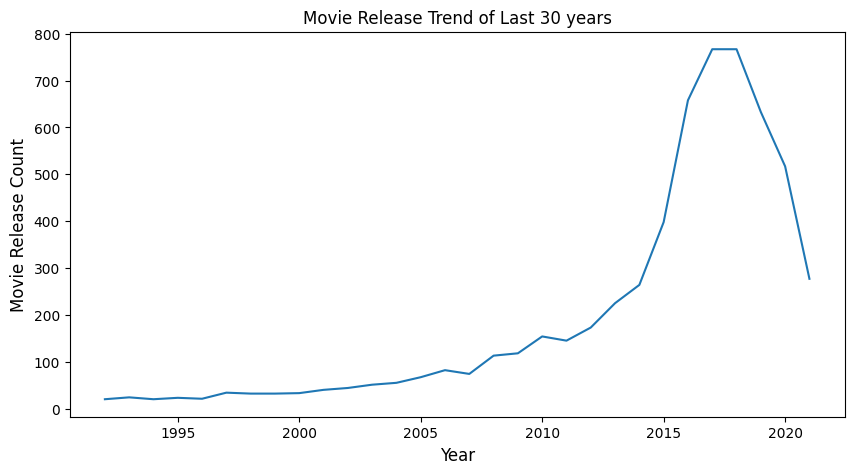

In [24]:
# Visualization of movie release count for last 30 years

# Plot graph for trend
plt.figure(figsize=(10, 5))
sns.lineplot(data=last_30_year_movie_release, x="release_year", y="Count")
plt.title("Movie Release Trend of Last 30 years")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Movie Release Count", fontsize=12)

plt.show()

1. Movie releases grew significantly from 1992 to 2018, then declined sharply from 2019 to 2021.
2. Movie releases peaked in the year 2017 and 2018.
3. Based on the analysis, Netflix movie catalog is strongly concentrated in recently released films.

**Analysis - Best Time to Launch a TV Show?**

In [25]:
# extracting month data from date_added and keeping it in new column
clean_data["date_added_month_number"] = clean_data["date_added"].dt.month
clean_data["date_added_month_name"] = clean_data["date_added"].dt.month_name()
# clean_data.head()

# Filter only TV shows and date_added_month
tv_show_data = clean_data.loc[clean_data["type"] == "TV Show", ["type", "date_added_month_number", "date_added_month_name"]]
# tv_show_data

# dataframe with type and it's count with date_added in "years"
tv_show_count_by_month = tv_show_data.groupby(["date_added_month_number", "date_added_month_name"])["date_added_month_name"].count().reset_index(name="Count")
# tv_show_count_by_month
tv_show_count_by_month[["date_added_month_name", "Count"]]

,date_added_month_name,Count
0,January,192
1,February,181
2,March,213
3,April,214
4,May,193
5,June,236
6,July,262
7,August,236
8,September,251
9,October,215


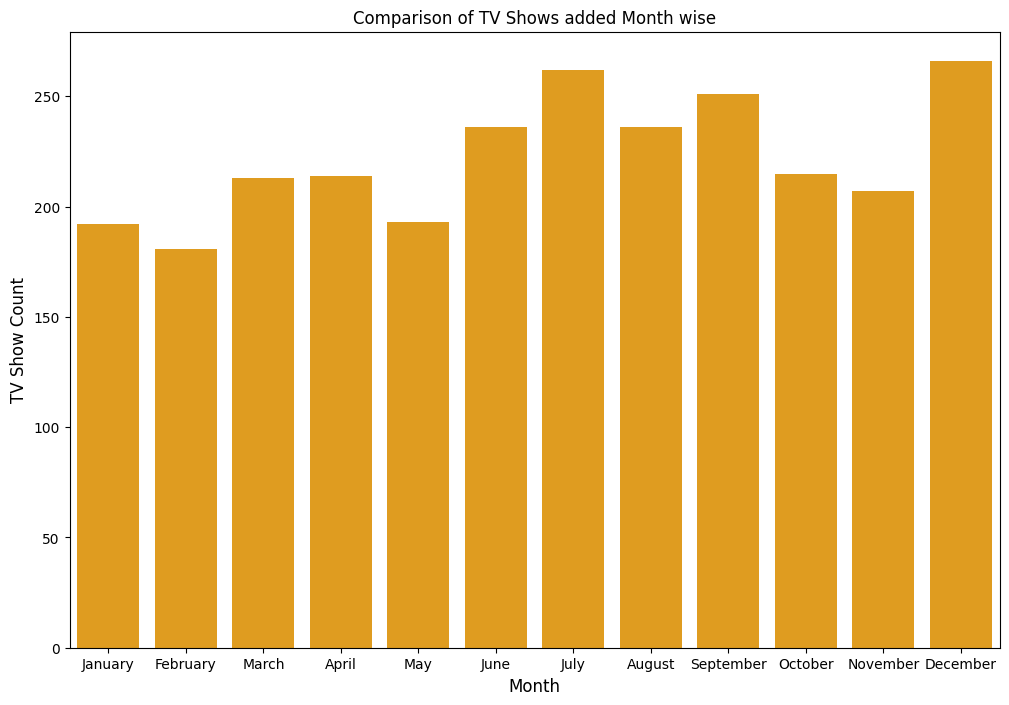

In [26]:
# Visualization of TV shows count monthly
plt.figure(figsize=(12,8))
sns.barplot(data=tv_show_count_by_month[["date_added_month_name", "Count"]], x="date_added_month_name", y="Count", color="orange")
plt.xlabel("Month", fontsize=12)
plt.ylabel("TV Show Count", fontsize=12)
plt.title("Comparison of TV Shows added Month wise")

plt.show()

1. July and December months have the highest addition for TV shows.
2. February and May have the lowest addtion for TV shows.
3. Overall, Q3 shows the strongest addition of TV show content while Q1 shows lowest quarter.
4. Mid-year as well as end of the year shows a push in TV show content addition.

**Analysis - Does Netflix has more focus on TV Shows than movies in recent years**

In [27]:
# extracting year data from date_added and keeping it in new column
clean_data["date_added_year"] = clean_data["date_added"].dt.year.astype("Int64")
# clean_data.head()

# dataframe with type and it's count with date_added in "years"
type_trends_date_added_year = clean_data.groupby(["date_added_year", "type"]).size().reset_index(name="count")
# type_trends_date_added_year

# Filtering date added year for recent years (from 2016 onwards since Netflix went global and started adding more content from that year)
content_type_counts_per_year = type_trends_date_added_year[type_trends_date_added_year["date_added_year"] >= 2016]
content_type_counts_per_year

,date_added_year,type,count
12,2016,Movie,253
13,2016,TV Show,176
14,2017,Movie,839
15,2017,TV Show,349
16,2018,Movie,1237
17,2018,TV Show,412
18,2019,Movie,1424
19,2019,TV Show,592
20,2020,Movie,1284
21,2020,TV Show,595


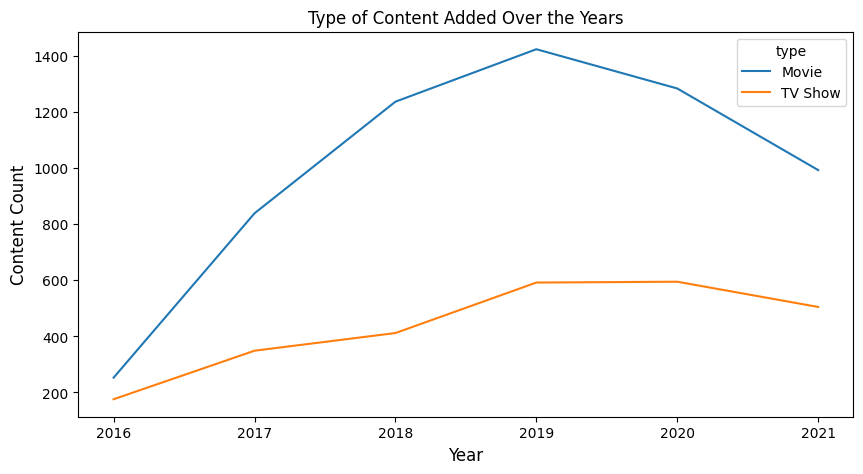

In [28]:
# Visualization of this trend
# Plot graph for trend
plt.figure(figsize=(10, 5))
sns.lineplot(data=content_type_counts_per_year, x="date_added_year", y="count", hue="type")
plt.title("Type of Content Added Over the Years")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Content Count", fontsize=12)

plt.show()

1. In recent years, movies continue to dominate the content catalogue of Netflix.
2. TV shows grew significantly from 2016 to 2019, then stable till 2020 and then started declining in 2020-2021.

**Genre Analysis**  
Genres are sorted in separate dataframe - "listed_in_data" 

In [29]:
listed_in_data.info()

<class 'pandas.DataFrame'>
Index: 19323 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       19323 non-null  str           
 1   type          19323 non-null  str           
 2   title         19323 non-null  str           
 3   director      13439 non-null  str           
 4   cast          17819 non-null  str           
 5   country       17601 non-null  str           
 6   date_added    19303 non-null  datetime64[us]
 7   release_year  19323 non-null  int64         
 8   rating        19317 non-null  str           
 9   duration      19320 non-null  str           
 10  listed_in     19323 non-null  str           
 11  description   19323 non-null  str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 1.9 MB


In [30]:
# Top overall genres
listed_in_data["listed_in"].value_counts().head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

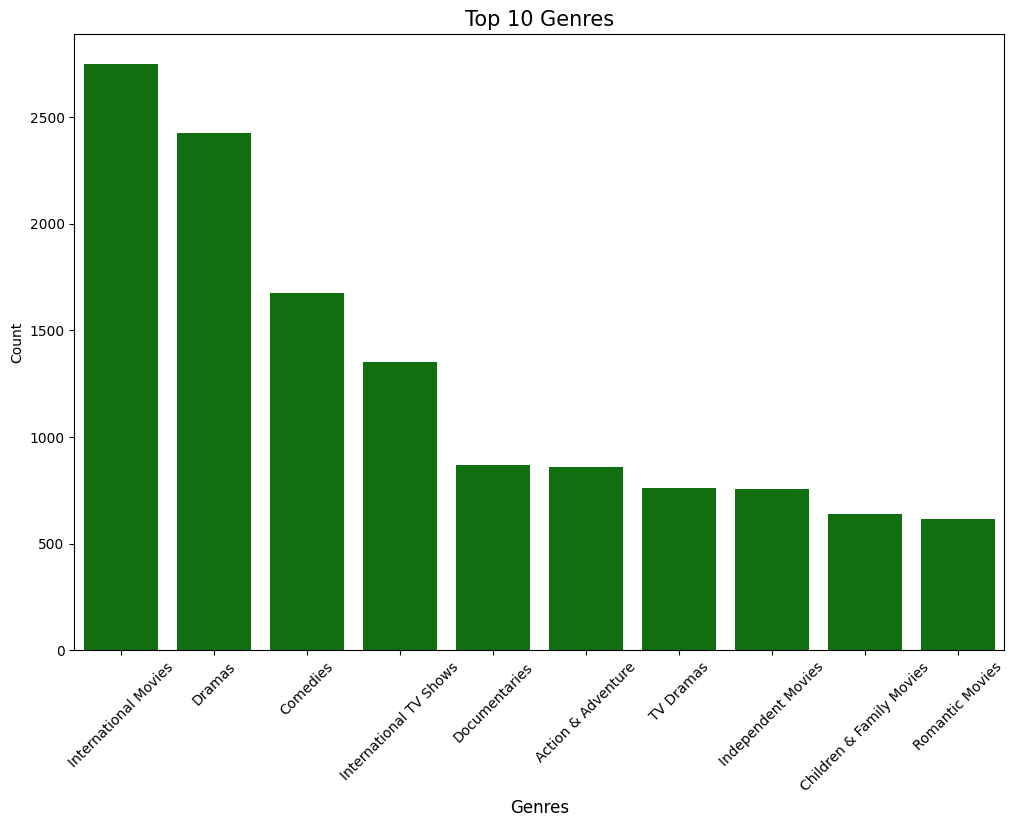

In [31]:
# top overall genres through visualization
top_genres = listed_in_data["listed_in"].value_counts(ascending=False).reset_index(name="Count").head(10)
# top_genres

# plot bar graph
plt.figure(figsize=(12, 8))
sns.barplot(data = top_genres, x="listed_in", y="Count", color="green")
plt.title("Top 10 Genres", fontsize=15)
plt.xlabel("Genres", fontsize=12)
plt.xticks(rotation=45)

plt.show()

In [32]:
# Top genres in Movies
listed_in_data[listed_in_data["type"] == "Movie"]["listed_in"].value_counts().head()

listed_in
International Movies    2752
Dramas                  2427
Comedies                1674
Documentaries            869
Action & Adventure       859
Name: count, dtype: int64

In [33]:
# Top genres in TV Show
listed_in_data[listed_in_data["type"] == "TV Show"]["listed_in"].value_counts().head()

listed_in
International TV Shows    1351
TV Dramas                  763
TV Comedies                581
Crime TV Shows             470
Kids' TV                   451
Name: count, dtype: int64

1. Top genres in Movie include:
   - International Movies
   - Dramas
   - Comedies
   - Documentaries
   - Action & Adventure.
2. Netflix has a broad movie genre collection.
3. Top genres in TV show include:
   - International TV Shows
   - TV Dramas
   - TV Comedies
   - Crime TV shows
   - Kids' TV.
4. Netflix TV show dominates comparitively more in "Internation TV Shows" category than other genres.
5. Netflix has highest content from "International Movies" and "International TV shows" category suggesting it diversifies global content. 

**Country Analysis**  
Countries are sorted in separate dataframe - "country_data"

In [34]:
country_data.info()

<class 'pandas.DataFrame'>
Index: 10843 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       10843 non-null  str           
 1   type          10843 non-null  str           
 2   title         10843 non-null  str           
 3   director      7874 non-null   str           
 4   cast          9839 non-null   str           
 5   country       10012 non-null  str           
 6   date_added    10833 non-null  datetime64[us]
 7   release_year  10843 non-null  int64         
 8   rating        10839 non-null  str           
 9   duration      10840 non-null  str           
 10  listed_in     10843 non-null  str           
 11  description   10843 non-null  str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 1.1 MB


In [35]:
# Top countries contributing to the content
top_contributing_countries = country_data["country"].value_counts(dropna=True).head(10)
top_contributing_countries = top_contributing_countries.index.to_list()
top_contributing_countries

['United States',
 'India',
 'United Kingdom',
 'Canada',
 'France',
 'Japan',
 'Spain',
 'South Korea',
 'Germany',
 'Mexico']

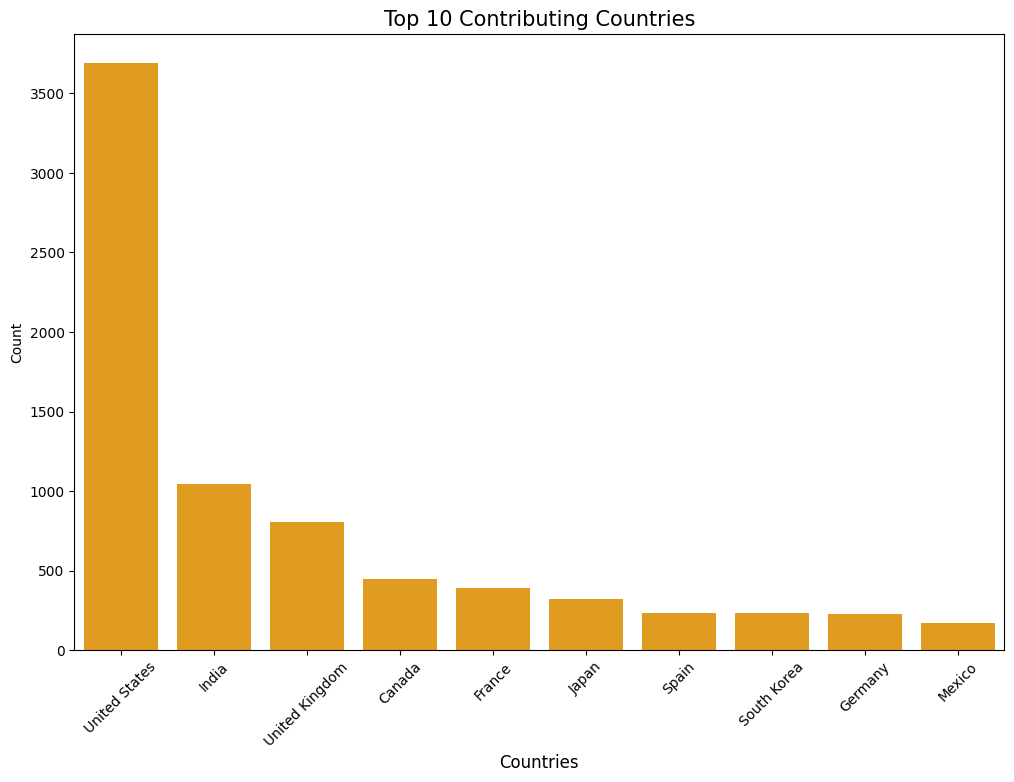

In [36]:
# Visualizing top content contributing countries to Netflix
top_contributing_countries_with_count = country_data["country"].value_counts(dropna=True).head(10).reset_index(name="Count")
top_contributing_countries_with_count

# plot bar graph
plt.figure(figsize=(12, 8))
sns.barplot(data = top_contributing_countries_with_count, x="country", y="Count", color="orange")
plt.title("Top 10 Contributing Countries", fontsize=15)
plt.xlabel("Countries", fontsize=12)
plt.xticks(rotation=45)

plt.show()

In [37]:
# Country wise Movies vs TV shows
countrywise_type_count = country_data.groupby(["country", "type"])["type"].size().unstack().fillna(0).astype("int").reset_index()
countrywise_type_count

type,country,Movie,TV Show
0,Afghanistan,1,0
1,Albania,1,0
2,Algeria,3,0
3,Angola,1,0
4,Argentina,71,20
...,...,...,...
121,Vatican City,1,0
122,Venezuela,4,0
123,Vietnam,7,0
124,West Germany,3,2


In [38]:
# creating a separate column for total content
countrywise_type_count["Shows"] = countrywise_type_count["Movie"] + countrywise_type_count["TV Show"]
countrywise_type_count

type,country,Movie,TV Show,Shows
0,Afghanistan,1,0,1
1,Albania,1,0,1
2,Algeria,3,0,3
3,Angola,1,0,1
4,Argentina,71,20,91
...,...,...,...,...
121,Vatican City,1,0,1
122,Venezuela,4,0,4
123,Vietnam,7,0,7
124,West Germany,3,2,5


In [39]:
# Top countries with total shows
top_countrywise_type_count = countrywise_type_count.sort_values(by="Shows", ascending=False).head(10).set_index("country")
top_countrywise_type_count

type,Movie,TV Show,Shows
country,,,
United States,2751,938,3689
India,962,84,1046
United Kingdom,532,272,804
Canada,319,126,445
France,303,90,393
Japan,119,199,318
Spain,171,61,232
South Korea,61,170,231
Germany,182,44,226


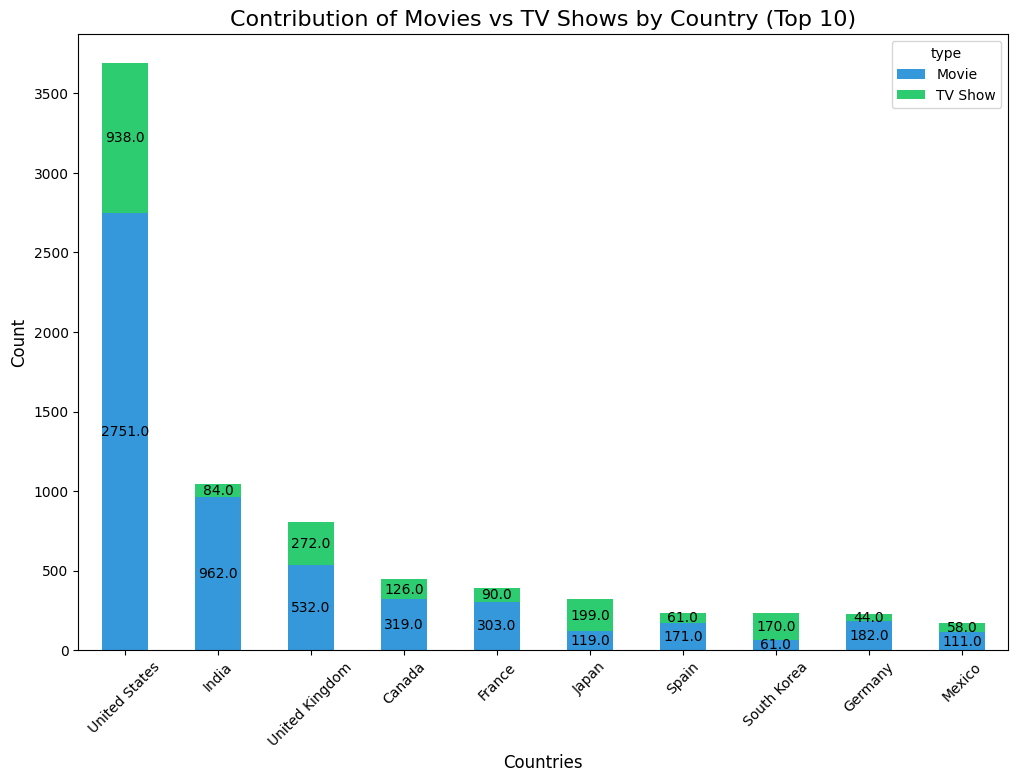

In [40]:
# Visualize this analysis

# Stacked Bar Chart will be good for this visualization
top_countrywise_type_count_stacked_bar = top_countrywise_type_count[["Movie", "TV Show"]].plot(
    kind='bar', stacked=True, figsize=(12,8), color=["#3498DB", "#2ECC71"]
)

# Add values to each segment
for container in top_countrywise_type_count_stacked_bar.containers:
    top_countrywise_type_count_stacked_bar.bar_label(container, label_type='center', fmt='%.1f')

plt.title("Contribution of Movies vs TV Shows by Country (Top 10)", fontsize=16)
plt.xlabel("Countries", fontsize=12)
plt.xticks(rotation=45)
plt.ylabel("Count", fontsize=12)

plt.show()

**Analysis - What type of content is available in different countries?**

1. **United States** has the most strongest library for both Movies and TV Shows.
2. **India** has the next strongest library with strong focus on movies and only some content on TV shows.
3. **Japan** and **South Korea** have more TV show catalog than movies.
4. **United Kingdom**, **Canada**, **France**, **Mexico** and **Germany** are movie dominant countries and very less TV shows.

In [41]:
# Analyzing Emerging Markets that is other countries apart from top 10 contributing countries who have contributed in recent years

# dataset which contains rows of countries except the top 10 countries
emerging_data = country_data[~country_data["country"].isin(top_contributing_countries)]
# emerging_data["country"].unique()

# Check the countries that started contributing in recent year since Netflix global expansion
recent_year_countries = emerging_data[(emerging_data["release_year"] >= 2016) & (emerging_data["release_year"] <= 2021)]["country"].value_counts(ascending=False)
# print(recent_year_countries)

# Check the countries that had contributed before 2016 year
past_year_countries = emerging_data[emerging_data["release_year"] < 2016]["country"].value_counts(ascending=False)
# print(past_year_countries)

# Joining both the data
emerging_countries = pd.concat([past_year_countries, recent_year_countries], axis=1)
# emerging_countries

# replace NaN with 0
emerging_countries.fillna(0, inplace=True)

# Assigning column name to concatenated data and also converting count type float to integers
emerging_countries.columns = ["Past_Releases_Count", "Recent_Releases_Count"]
emerging_countries = emerging_countries.astype("int")
# emerging_countries

# Adding column "Growth Count" for computing growth numbers
emerging_countries["Growth_Count"] = emerging_countries["Recent_Releases_Count"] - emerging_countries["Past_Releases_Count"]
# emerging_countries

# Filtering top 10 emerging countries with respect to contribution growth
top_emerging_countries = emerging_countries.sort_values("Growth_Count", ascending=False).head(10)
top_emerging_countries = top_emerging_countries.reset_index()
top_emerging_countries

,country,Past_Releases_Count,Recent_Releases_Count,Growth_Count
0,China,40,122,82
1,Brazil,14,83,69
2,Nigeria,21,82,61
3,Argentina,19,72,53
4,Belgium,24,66,42
5,Italy,29,71,42
6,Indonesia,26,64,38
7,Australia,63,97,34
8,Colombia,9,43,34
9,South Africa,19,43,24


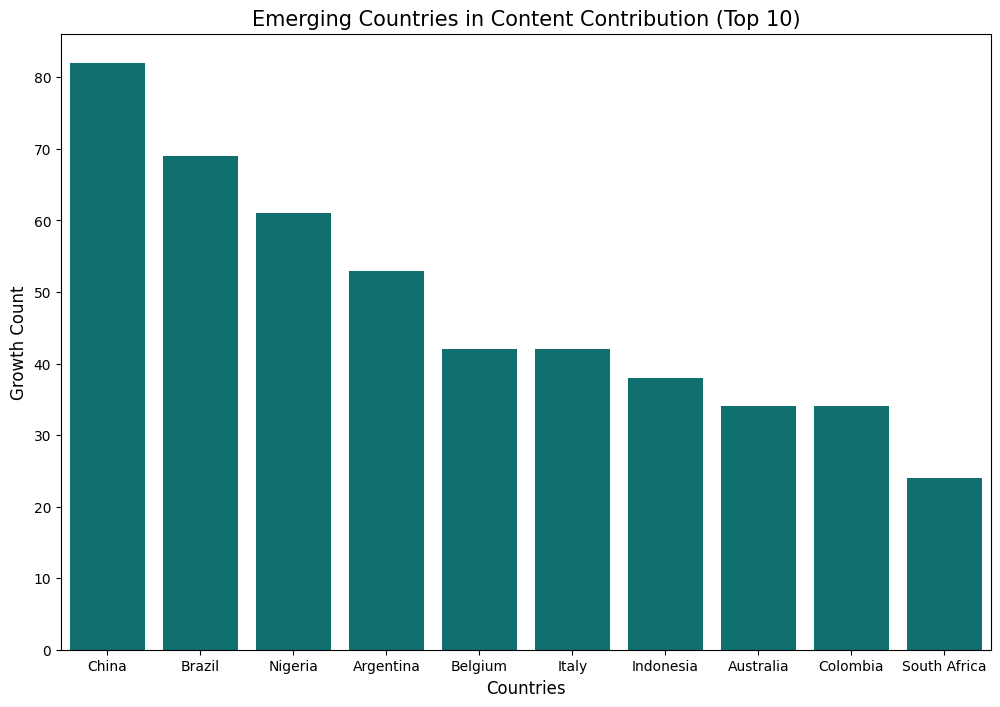

In [42]:
# Visualize the top growth count using bar chart
plt.figure(figsize=(12,8))
sns.barplot(data=top_emerging_countries, x="country", y="Growth_Count", color="teal")
plt.xlabel("Countries", fontsize=12)
plt.ylabel("Growth Count", fontsize=12)
plt.title("Emerging Countries in Content Contribution (Top 10)", fontsize=15)

plt.show()

In [43]:
# Analyzing ratings in top contributing countries

country_ratings_count = country_data.groupby(["country", "rating"])["rating"].count().reset_index(name="counts")
country_ratings_count

,country,rating,counts
0,Afghanistan,TV-MA,1
1,Albania,TV-MA,1
2,Algeria,TV-14,1
3,Algeria,TV-MA,2
4,Angola,TV-MA,1
...,...,...,...
512,West Germany,TV-14,1
513,West Germany,TV-MA,3
514,Zimbabwe,NR,1
515,Zimbabwe,TV-G,1


In [44]:
# Filter for top countries
top_countries = country_data[country_data["country"].isin(top_contributing_countries)]
# top_countries

# Countrywise ratings and counts
top_countries_ratings = top_countries.groupby(["country", "rating"])["title"].count().reset_index(name="counts")
# top_countries_ratings

# Sort the counts for each country
top_countries_ratings_sorted = top_countries_ratings.sort_values(["country", "counts"], ascending=[True, False])
# top_countries_ratings_sorted

# Top 3 ratings per country
top_countries_top_ratings = top_countries_ratings_sorted.groupby("country").head(3)
# top_countries_top_ratings

# creating a column with count percentage
total_ratings_count_per_country = country_ratings_count.groupby("country")["counts"].sum()
# total_ratings_count_per_country

# creating total_counts column with sum of counts of top 3 ratings of that country
top_countries_top_ratings["total_ratings_count"] = top_countries_top_ratings["country"].map(total_ratings_count_per_country)

# Creating counts percentage column with percentage of total ratings for that particular rating in that country
top_countries_top_ratings["ratings count %"] = np.round((top_countries_top_ratings["counts"] / top_countries_top_ratings["total_ratings_count"]) * 100, 2)
top_countries_top_ratings

,country,rating,counts,total_ratings_count,ratings count %
8,Canada,TV-MA,107,445,24.04
5,Canada,R,79,445,17.75
6,Canada,TV-14,49,445,11.01
21,France,TV-MA,163,393,41.48
18,France,R,57,393,14.50
19,France,TV-14,48,393,12.21
33,Germany,TV-MA,79,226,34.96
30,Germany,R,43,226,19.03
29,Germany,PG-13,31,226,13.72
41,India,TV-14,572,1046,54.68


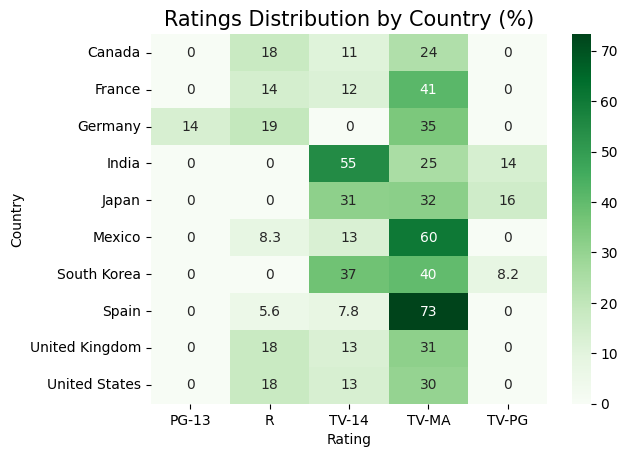

In [45]:
# Visualization for this analysis
top_countries_heatmap_data = pd.pivot(data=top_countries_top_ratings, index="country", columns="rating", values="ratings count %").fillna(0)
# top_countries_heatmap_data

# Plot heatmap graph for this data
sns.heatmap(data=top_countries_heatmap_data, annot=True, cmap="Greens")

plt.title("Ratings Distribution by Country (%)", fontsize=15)
plt.xlabel("Rating")
plt.ylabel("Country")
plt.show()

1. **Spain** has focused it's content library heavily to attract mature audience with TV-MA with 73% ratings.
2. Similar story with **Mexico** strongly aligning it's content to attract mature audience with TV-MA ratings of 60%
3. **India's** content catalog looks to attract more teenagers with TV-14 rated content at 55%
4. **United States** and **United Kingdom** content library are heavily focused on mature audience with 31% and 30% respectively in TV-MA rating.
5. **Japan** shows a balanced content between TV-14 and TV-MA, suggesting content available for both mature and teen/young audience.
6. Similarly, **South Korea** also shares a balance content between TV-14 and TV-MA ratings.

In [46]:
# Analyzing ratings vs countries for top 10 emerging countries

# Filter country data for top emerging countries
top_emerging_countries = country_data[country_data["country"].isin(top_emerging_countries["country"].to_list())]
# top_emerging_countries

# Countrywise ratings and counts
top_emerging_countries_ratings = top_emerging_countries.groupby(["country", "rating"])["title"].count().reset_index(name="counts")
# top_emerging_countries_ratings

# Sort the counts for each country
top_emerging_countries_ratings_sorted = top_emerging_countries_ratings.sort_values(["country", "counts"], ascending=[True, False])
# top_emerging_countries_ratings_sorted

# Top 3 ratings per country
top_emerging_countries_top_ratings = top_emerging_countries_ratings_sorted.groupby("country").head(3)
# top_emerging_countries_top_ratings

# creating a column with count percentage
total_ratings_count_per_country = country_ratings_count.groupby("country")["counts"].sum()
# total_ratings_count_per_country

# creating total_counts column with sum of counts of top 3 ratings of that country
top_emerging_countries_top_ratings["total_ratings_count"] = top_emerging_countries_top_ratings["country"].map(total_ratings_count_per_country)

# Creating counts percentage column with percentage of total ratings for that particular rating in that country
top_emerging_countries_top_ratings["ratings count %"] = np.round(
    (top_emerging_countries_top_ratings["counts"] / top_emerging_countries_top_ratings["total_ratings_count"]) * 100, 2
)
top_emerging_countries_top_ratings

,country,rating,counts,total_ratings_count,ratings count %
6,Argentina,TV-MA,67,91,73.63
4,Argentina,TV-14,10,91,10.99
7,Argentina,TV-PG,4,91,4.40
15,Australia,TV-MA,44,159,27.67
12,Australia,R,21,159,13.21
13,Australia,TV-14,21,159,13.21
26,Belgium,TV-MA,46,90,51.11
24,Belgium,R,17,90,18.89
25,Belgium,TV-14,7,90,7.78
36,Brazil,TV-MA,59,97,60.82


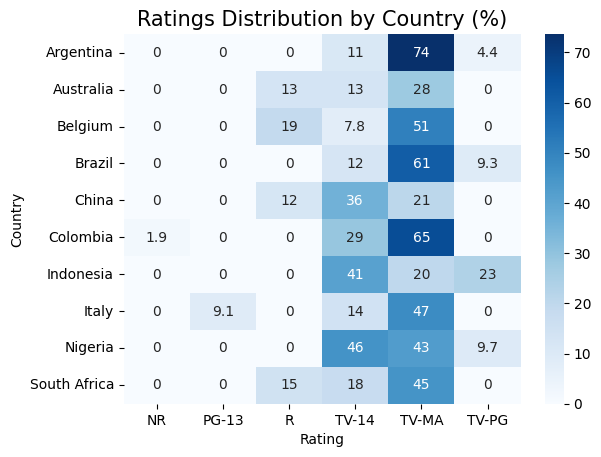

In [47]:
# Visualization for this analysis
emerging_coutries_heatmap_data = pd.pivot(data=top_emerging_countries_top_ratings, index="country", columns="rating", values="ratings count %").fillna(0)
# emerging_coutries_heatmap_data

# Plot heatmap graph for this data
sns.heatmap(data=emerging_coutries_heatmap_data, annot=True, cmap="Blues")

plt.title("Ratings Distribution by Country (%)", fontsize=15)
plt.xlabel("Rating")
plt.ylabel("Country")
plt.show()

1. Mosty of the top 10 emerging countries have aligned their content library for mature audience (TV-MA).
2. **Argentina** with 74% is strongly TV-MA focused suggesting it's content mainly attracts mature audience.
3. **Columbia** also with 65% is heavily TV-MA focused.
4. Similarly **Brazil** with 61% is content catalog is mature-audience focused.
5. **China, Indonesia and Nigeria** have focused their content on TV-14.
6. **South Africa** however have mixed content library which includes TV-MA (45%), TV-14 (18%) and R rated (15%)
7. Overall, in emerging market countries, South American countries like Argentina, Brazil and Colombia are strongly mature-content oriented, while Asian countries like China and Indonesia have focused more toward TV-14, TV-MA and TV-PG audience.

**Duration Analysis**

In [48]:
clean_data["duration"].unique()

<StringArray>
[   '90 min', '2 Seasons',  '1 Season',    '91 min',   '125 min', '9 Seasons',
   '104 min',   '127 min', '4 Seasons',    '67 min',
 ...
    '43 min',   '200 min',   '196 min',   '167 min',   '178 min',   '228 min',
    '18 min',   '205 min',   '201 min',   '191 min']
Length: 221, dtype: str

Since duration contains mix of **min** and **Seasons**, need to segregate the data and analyse.

**Part 1: Movies duration analysis**

In [49]:
# Filtering movies using duration column
movies_data = clean_data[clean_data["duration"].str.contains("min")]
# movies_data

# extracting value from mins duration
movies_data["duration"] = movies_data["duration"].replace(r" min", "", regex=True).astype("int64")
# movies_data
# movies_data.info()

# checking stats of duration for movies
# movies_data["duration"].mean(), movies_data["duration"].max(), movies_data["duration"].min(), movies_data["duration"].mode()[0]
print(f"The average run time of movies is {np.round(movies_data["duration"].mean(),2)} mins.")
print(f"The longest run time among all the movies is {movies_data["duration"].max()} mins.")
print(f"The shortest run time among all the movies is {movies_data["duration"].min()} mins.")
print(f"The most common movie runtime is {movies_data["duration"].mode()[0]} mins.")

The average run time of movies is 99.58 mins.
The longest run time among all the movies is 312 mins.
The shortest run time among all the movies is 3 mins.
The most common movie runtime is 90 mins.


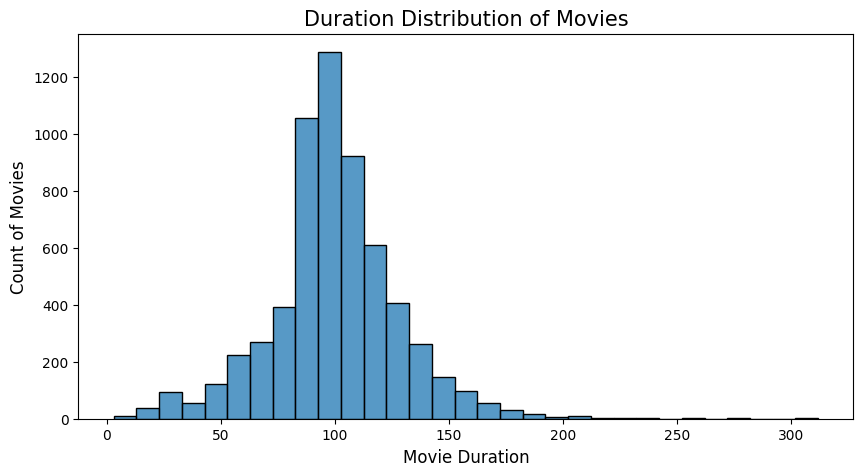

In [50]:
# Visualization for distribution of movies based on duration
mins_bin = [0, 50, 100, 150, 200, 250, 300, 350]

plt.figure(figsize=(10,5))
sns.histplot(data=movies_data, x="duration", binwidth=10)
plt.xlabel("Movie Duration", fontsize=12)
plt.ylabel("Count of Movies", fontsize=12)
plt.title("Duration Distribution of Movies", fontsize=15)

plt.show()

1. Most of the movies fall in 90 to 120 mins of duration, with most common movie duration is 90 mins.
2. More than 1200 movies having run time around 100 mins, suggesting that movies with around 1.5 hour run time are present in Netflix movie catalog.
3. There are very less movies which have run time below 90 mins and above 130 mins.

**Part 2: TV Show Seasons analysis**

In [51]:
# Extracting TV shows using Seasons string
tv_show_data = clean_data[clean_data["duration"].str.contains("Season")]
# tv_show_data

# extracting value from Seasons string
tv_show_data["duration"] = tv_show_data["duration"].replace(r" (Seasons?|Season)", "", regex=True).astype("int64")
# tv_show_data
# tv_show_data.info()

# checking stats of duration for movies
# tv_show_data["duration"].mean(), tv_show_data["duration"].max(), tv_show_data["duration"].min(), tv_show_data["duration"].mode()[0]
print(f"The average duration of a TV Show is {np.round(tv_show_data["duration"].mean(),2)} Season(s).")
print(f"The longest duration among all the TV Shows is {tv_show_data["duration"].max()} Season(s).")
print(f"The shortest duration among all the TV shows is {tv_show_data["duration"].min()} Season(s).")
print(f"The most common duration of TV shows is {tv_show_data["duration"].mode()[0]} Season(s)")

The average duration of a TV Show is 1.76 Season(s).
The longest duration among all the TV Shows is 17 Season(s).
The shortest duration among all the TV shows is 1 Season(s).
The most common duration of TV shows is 1 Season(s)


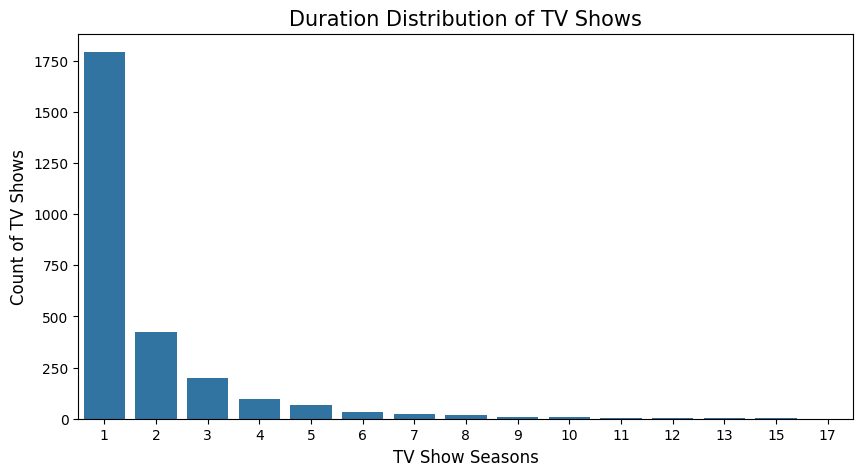

In [52]:
# Visualization for distribution of TV Show based on duration

plt.figure(figsize=(10,5))
sns.countplot(data=tv_show_data, x="duration")
plt.xlabel("TV Show Seasons", fontsize=12)
plt.ylabel("Count of TV Shows", fontsize=12)
plt.title("Duration Distribution of TV Shows", fontsize=15)

plt.show()

1. Most of the TV Shows duration is 1 to 2 seasons, with most common TV show duration is 1 season.
2. More than 1700 TV Shows have only 1 season, suggesting TV shows with 1 season are most common in Netflix TV show catalog.
3. There are very less TV Shows which have more than 2 seasons.

**Analysis of actors/directors of different types of shows/movies.**

**Part 1: Top Actors in Movies**

In [53]:
# For cast, need to use exploded cast data
# cast_data

# Filtering only movies
actors_movies_data = cast_data.loc[cast_data["type"] == "Movie", ["type", "cast"]]
# actors_movies_data.shape[0]
# actors_movies_data.isna().sum()

# Out of total rows, NaN values are negligible which will not affect the accuracy of the data analysis, so removing null rows
actors_movies_data = actors_movies_data.dropna(subset=["cast"], axis=0)
# actors_movies_data.isna().sum()
# actors_movies_data

# Group by cast and count the cast
actors_movie_count = actors_movies_data.groupby("cast")["cast"].count().reset_index(name="Count")
# actors_movie_count

# sort top 10 actors for movies
top_actors_for_movies = actors_movie_count.sort_values(by="Count", ascending=False).head(10)
top_actors_for_movies

,cast,Count
2105,Anupam Kher,42
21781,Shah Rukh Khan,35
17193,Naseeruddin Shah,32
18064,Om Puri,30
638,Akshay Kumar,30
12031,Julie Tejwani,28
1313,Amitabh Bachchan,28
18329,Paresh Rawal,28
3354,Boman Irani,27
20692,Rupa Bhimani,27


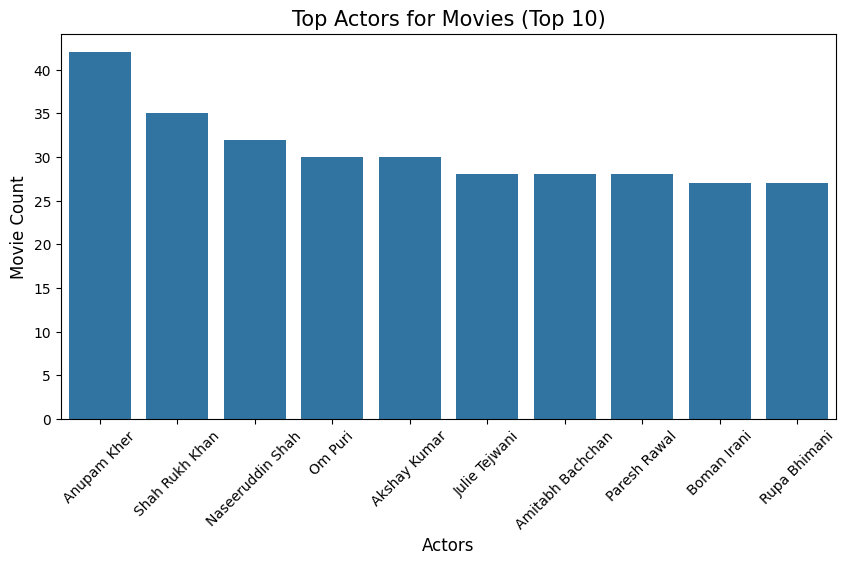

In [54]:
# Visualization of top actors for movies

plt.figure(figsize=(10, 5))
sns.barplot(data=top_actors_for_movies, x="cast", y="Count")
plt.xlabel("Actors", fontsize=12)
plt.xticks(rotation=45)
plt.ylabel("Movie Count", fontsize=12)
plt.title("Top Actors for Movies (Top 10)", fontsize=15)

plt.show()

**Part 2: Top Actors in TV Shows**

In [55]:
# For cast, need to use exploded cast data
# cast_data

# Filtering only movies
actors_tv_data = cast_data.loc[cast_data["type"] == "TV Show", ["type", "cast"]]
# actors_tv_data.shape[0]
# actors_tv_data.isna().sum()

# Out of total rows, NaN values are negligible which will not affect the accuracy of the data analysis, so removing null rows
actors_tv_data = actors_tv_data.dropna(subset=["cast"], axis=0)
# actors_tv_data.isna().sum()
# actors_tv_data

# # Group by cast and count the cast
actors_tv_count = actors_tv_data.groupby("cast")["cast"].count().reset_index(name="Count")
# actors_tv_count

# sort top 10 actors for TV shows
top_actors_for_tv = actors_tv_count.sort_values(by="Count", ascending=False).head(10)
top_actors_for_tv

,cast,Count
13230,Takahiro Sakurai,25
14580,Yuki Kaji,19
252,Ai Kayano,17
6804,Junichi Suwabe,17
2874,Daisuke Ono,17
14564,Yuichi Nakamura,16
14496,Yoshimasa Hosoya,15
6761,Jun Fukuyama,15
3127,David Attenborough,14
14500,Yoshitsugu Matsuoka,13


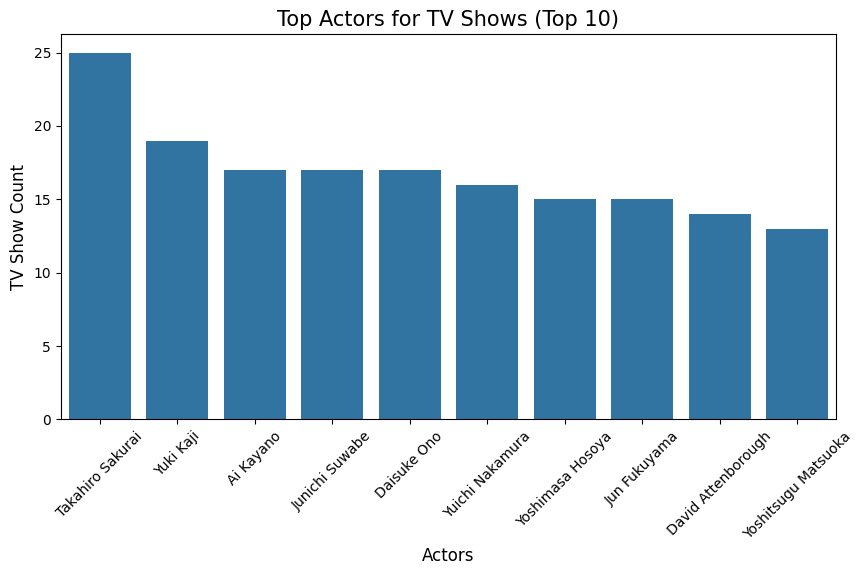

In [56]:
# Visualization of top actors for TV Shows

plt.figure(figsize=(10, 5))
sns.barplot(data=top_actors_for_tv, x="cast", y="Count")
plt.xlabel("Actors", fontsize=12)
plt.xticks(rotation=45)
plt.ylabel("TV Show Count", fontsize=12)
plt.title("Top Actors for TV Shows (Top 10)", fontsize=15)

plt.show()

In [57]:
# Check if any actor is present in both top 10 Movies and TV shows
top_actors_for_movies[top_actors_for_movies["cast"].isin(top_actors_for_tv["cast"])]

,cast,Count


1. Actor **Anupam Kher** dominates the Movie catalog in Netflix.
2. Actor **Takahiro Sakurai** dominates the TV shows catalog in Netflix.
3. Movie actors are **different** from TV actors.

**Part 3: Top Directors in Movies**

In [58]:
# For directors, need to use exploded director data
# director_data

# Filtering only movies
director_movies_data = director_data.loc[director_data["type"] == "Movie", ["type", "director"]]
# director_movies_data.shape[0]
# director_movies_data.isna().sum()

# Out of total rows, NaN values are negligible which will not affect the accuracy of the data analysis, so removing null rows
director_movies_data = director_movies_data.dropna(subset=["director"], axis=0)
# director_movies_data.isna().sum()
# director_movies_data

# Group by directors and count the directors
director_movie_count = director_movies_data.groupby("director")["director"].count().reset_index(name="Count")
# director_movie_count

# sort top 10 directors for movies
top_directors_for_movies = director_movie_count.sort_values(by="Count", ascending=False).head(10)
top_directors_for_movies

,director,Count
3582,Rajiv Chilaka,22
1817,Jan Suter,21
3633,Raúl Campos,19
4261,Suhas Kadav,16
2739,Marcus Raboy,15
1862,Jay Karas,15
727,Cathy Garcia-Molina,13
1859,Jay Chapman,12
2815,Martin Scorsese,12
4725,Youssef Chahine,12


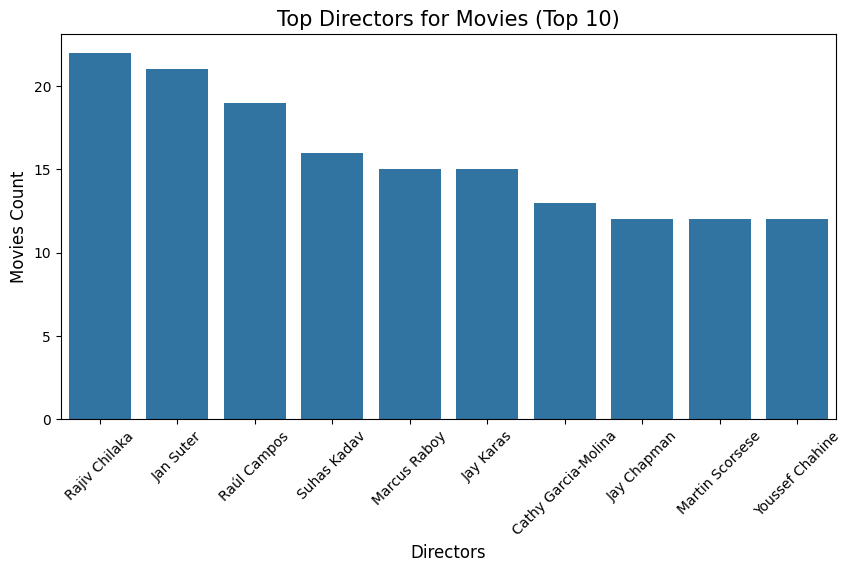

In [59]:
# Visualization of top directors for Movies

plt.figure(figsize=(10, 5))
sns.barplot(data=top_directors_for_movies, x="director", y="Count")
plt.xlabel("Directors", fontsize=12)
plt.xticks(rotation=45)
plt.ylabel("Movies Count", fontsize=12)
plt.title("Top Directors for Movies (Top 10)", fontsize=15)

plt.show()

**Part 4: Top Directors in TV Shows**

In [60]:
# For directors, need to use exploded director data
# director_data

# Filtering only TV shows
director_tv_data = director_data.loc[director_data["type"] == "TV Show", ["type", "director"]]

# director_tv_data.shape[0] = 2758
# director_tv_data.isna().sum() = 2446

**Total Rows are 2758 and 2446 rows have missing Directors, suggesting director information is almost unavailable for TV Shows, suggesting that TV Show content may not be organized by individual directors.**  
**Filtering the null values and proceeding with analysis for top directors in TV Shows but will point out the same in insights.**

In [61]:
# Filter NaN values from available data
director_tv_data = director_tv_data.dropna(subset=["director"], axis=0)
# director_tv_data.isna().sum()
# director_tv_data

# Group by directors and count the directors
director_tv_count = director_tv_data.groupby("director")["director"].count().reset_index(name="Count")
# director_tv_count

# sort top 10 directors for movies
top_directors_for_tv = director_tv_count.sort_values(by="Count", ascending=False).head(10)
top_directors_for_tv

,director,Count
8,Alastair Fothergill,3
146,Ken Burns,3
140,Jung-ah Im,2
103,Iginio Straffi,2
128,Joe Berlinger,2
84,Gautham Vasudev Menon,2
100,Hsu Fu-chun,2
168,Lynn Novick,2
235,Rob Seidenglanz,2
251,Shin Won-ho,2


1. Director **Rajiv Chilaka** dominates the Movie catalog in Netflix.
2. TV Shows in Netflix are less driven by **Directors** and may have been more driven by **Teams, studios or content creators.**
3. Due to high missing data for **TV Show directors**, the analysis may not fully represent actual industry patterns.

### Business Insights

**Content Type Insights**
1. **Movies dominate about 70%** of Netflix catalog while **TV Shows are 30%**, which suggests Netflix relies heavily on movies in its content library diversity.
2. **TV shows improved significantly during the year of 2016 to 2019**, which suggests Netflix recently started including TV shows in its library.
3. **Movies continue to dominate** the content library while **Netflix is increasing TV shows** to attract different types of audiences.  

**Content Genre Insights**  
4. **International Movies, Dramas, Comedies, Documentaries and Action & Adventure** are the top genres in Movies.  
5. **International TV Shows, TV Dramas, TV Comedies, Crime TV shows and Kids' TV** are the top genres in TV Shows.  
6. **Netflix has inclusion of international content** in its library to diversify its content offerings.  

**Country Insights**  
7. **United States** has the largest catalog for movies and TV shows followed by **India**, which has large focus on movies while fewer on TV shows.  
8. **Japan and South Korea** have more TV show content than movies.  
9. **United Kingdom, Canada, France, Mexico and Germany** are movie dominant countries and fewer TV shows.  
10. **Emerging countries like China, Brazil, Nigeria, Argentina, Belgium, Indonesia, and South Africa** show strong growth in content contribution, suggesting Netflix is expanding globally beyond its established markets.  

**Ratings and Audience Analysis**  
11. **Spain** content catalog heavily leans towards mature audience with **TV-MA with 73% ratings.**  
12. **Mexico** shows similar patterns with **TV-MA ratings of 60%**  
13. **India's** content catalog leans more towards teenagers with **TV-14 rated content at 55%**  
14. **United States and United Kingdom** content library are heavily focused on mature audience with **31% and 30% respectively in TV-MA rating.**  
15. **Japan shows a balanced content between TV-14 and TV-MA**, suggesting content available for both mature and teen/young audience.  
16. **South Korea** also shares a **balanced content between TV-14 and TV-MA ratings.**  
17. **Emerging countries like Argentina, Columbia and Brazil**, have content heavily focused towards **mature audience (TV-MA).**  
18. **China, Indonesia and Nigeria** have focused their content on **TV-14**, while **South Africa** has balanced content between **TV-MA, TV-14 and R rated.**  

**Duration Analysis**  
19. **Most movies are between 90 and 120 minutes**, with **90 minutes being the most common runtime**, suggesting that Netflix prefers standard length duration for movies.  
20. **Most of the TV Shows have 1-2 seasons**, with **TV shows with 1 season being the most common**, suggesting that Netflix prefers limited seasons or short run shows.  

**Actors and Directors Insights**  
21. **Movie actors and TV actors differ**, suggesting Netflix prefers different casts for different content type.  
22. **Some actors appear frequently in the movies** suggesting Netflix prefers to re-cast familiar or commercially successful actors.  
23. **Directors appear more in Movies than TV shows** suggesting that Movies are more driven by directors than TV shows.  
24. **TV Shows have multiple missing directors** suggesting the TV series may have been produced by a production house or studios rather than a single director.  

**Content Release Trends Insights**  
25. **Content additions increased tremendously from 2016** since Netflix expanded it's offerings globally.  
26. **TV show additions were strongest in mid-year and end of the year** suggesting Netflix prefers to release content during holidays, vacations and festive seasons.  

### Business Recommendations

1. **Continue to add movies to content** since they are a part of major Netflix content type and also attract viewers worldwide.
2. **TV shows are also gaining traction in recent years so continue to add TV show content**, which will help to improve content variety among viewers worldwide.
3. **Adding Intenational content to Netflix is helping** so continue investing more on international movie and TV shows.
4. **Continue investing in genres like Dramas, Comedies, Documentaries and Action & Adventures** since they are popular in both movies and TV shows.
5. **Invest more in emerging markets like China, Brazil, Nigeria, Argentina, Belgium, Indonesia, and South Africa** since they have started contributing more in recent years.
6. **Maintain strong movie content library in USA and India** while also increasing TV shows that these countries prefer.
7. **Continue to add more TV shows in Japan and South Korea** while also promoting movies of their preferences.
8. **Use the content ratings to release similar content in countries** where audience prefers, like family shows where audience type is balanced and mature shows to mature audiences.
9. **Plan Movies and TV show releases in months of July, September and December** to engage high volume of viewers.
10. **Maintain a standard movie runtime of 90 to 120 minutes and TV shows with 1 to 2 seasons** to get engage more number of viewers.
11. **Continue to work with frequently appearing actors and directors** since they may bring a lot of viewers to Netflix platform.
12. **TV show database needs to be improved** specially director information to enable accurate analysis and better recommendations.